# [The StatQuest Illustrated Guide to Machine Learning](https://www.amazon.com/StatQuest-Illustrated-Guide-Machine-Learning/dp/B09ZCKR4H6)

# Chapter XX - Clustering

Copyright 2026, Joshua Starmer

In this notebooke we'll...

- Load data from a file into a **DataFrame**
- Draw a 2-D scatter plot with using two columns from the data
- Cluster the data based on 2-D distances using **DBSCAN** and **K-means**
- Redraw the 2-D scatter plot with the clustering labels
- Apply **PCA** on three columns from the data to reduce the dimension to 2
- Draw a **PCA** scatter plot plot of the data using the principal components.
- Cluster the data based on 3-D distances using **DBSCAN** and **K-means**
- Redraw the **PCA** scatter plot with the 3-D clustering labels.

----

# Load data from a file

The first thing we need to do is get our data.

However, before we get to that, we have to load in some modules that will help us load, plot, and cluster data.

In [32]:
## NOTE: cuML is NVIDIA's library to speed up sklearn.
## Basically it allows us to run sklearn on the GPU without
## having to change our code.
## NOTE: the "cu" is short of CUDA, which is NVIDIA's 
## platform for accelerating things with a GPU
##
## cuML is preinstalled on Google Colab - so we can not use it 
## and then see the speed up when using it. bam.
##
#%load_ext cuml.accel

import pandas as pd # to import data into a dataframe
import numpy as np # to round some numbers...
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
import warnings ## to supress some runtime warnings by kmeans
from sklearn.decomposition import PCA ## to process and plot data with more than 2 dimensions
from sklearn.preprocessing import StandardScaler

Now we can load in data. We'll use the Pandsa function `read_csv()`, where we need to specify the name of the file (and the path to the file, if necessary), and the character used to separate the columns of data. In this case, `geochem_data.txt` is a comma-delimited file so we'll set `sep='\t'`.

In [49]:
## First, use pd.read_csv() to read the data in "geochem_data.txt"
geochem_data = pd.read_csv("geochem_data.txt", sep="\t")

# Verify that read_csv() was successful by printing out the first few rows
geochem_data.head()

,latitude,longitude,depth,LITH,Fe,Th,U,P
0,1304.863397,74710.84587,-420.016808,A,-2.83,-3.55,-2.20,-0.60
1,1304.875714,74710.84154,-420.047116,A,-1.36,-1.43,-1.48,-1.97
2,1304.887496,74710.83741,-420.076037,A,-2.03,-0.91,-1.79,-1.01
3,1304.899862,74710.83307,-420.106322,A,-1.43,-5.58,-2.96,-2.31
4,1304.912803,74710.82849,-420.137974,A,-4.31,-1.71,-1.43,-2.26


Now let's see how many rows of data we have...

In [50]:
## print out the number of rows and columns...
geochem_data.shape ## returns (# rows, # columns)

(499, 8)

**Bam!**

Now that we've loaded the data, let's draw some plots and cluster it.

----

# Drawing an initial plot

Now let's draw a 2-D plot the data based only on `latitude` and `longitude`. We'll save `depth` for later...

<Axes: xlabel='latitude', ylabel='longitude'>

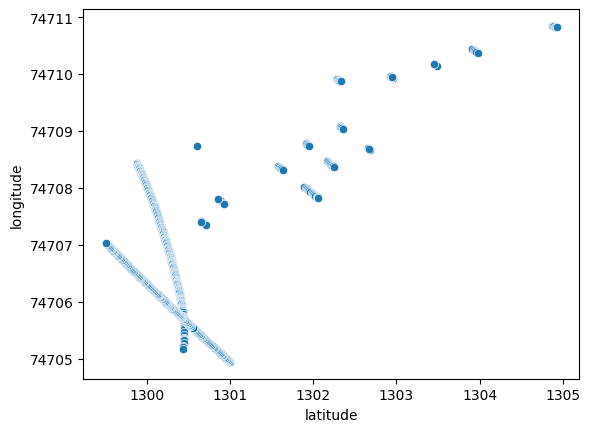

In [82]:
sns.scatterplot(data=geochem_data, x='latitude', y='longitude')

And the results are pretty interesting. It looks like there might be one or two large clusters and a handful of small clusters. Now let's see what kinds of clustering we get when we apply **DBSCAN** and **K-means** clustering to the data.

----

# Identifying clusters with DBSCAN, part 1, 2-d dataset

To start with, we're just going to look for clusters with just the `latitude` and `longitude` data, and see if they correspond to what we saw in the plot we just drew. To do this, we'll start by creating a new DataFrame that just has 2-Dimensional data `latitude` and `longitude`.



In [83]:
## extract just the latitude and longitude data
coords_2d = geochem_data[['latitude', 'longitude']]
coords_2d.head()

,latitude,longitude
0,1304.863397,74710.84587
1,1304.875714,74710.84154
2,1304.887496,74710.83741
3,1304.899862,74710.83307
4,1304.912803,74710.82849


Now we can search for clusters with **DBSCAN**.

**DBSCAN** has two parameters that we'll need to set, `epsilon`, the maximum distance between two samples for one to be considered as in the neighborhood of the other, and `min_samples`, the number of samples in a neighborhood for a point to be considered as a **core** point. Both of these parameters can be a little tricky because they can depend on the scale of your data. The way I found good values for them was to look at the x and y-axes in the original 2-D graph we drew above to get a sense of the general scale of things. Alternatively, you could scale the data (i.e. standardize it) in advance and then good values might be less dataset dependent.

In [87]:
## Epsilon is the maximum distance between two samples
## for one to be considered as in the neighborhood of the other.
##
## NOTE: You'll have to fiddle with this parameter and find
##       a value that makes sense with your data.
epsilon = 0.25

## The number of samples in a neighborhood for a point 
## to be considered as a core point.
##
## NOTE: You'll have to fiddle with this parameter and find
##       a value that makes sense with your data.
min_samples = 25

## create a DBSCAN object
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

## run DBSCAN on the data
dbscan.fit(coords_2d)

# Get the cluster labels
dbscan_labels = dbscan.labels_

Now that we've run **DBSCAN**, we can see how many different clusters it identified by passing the labels in `dbscan_labels` to the `set()` function, which will remove all duplicates and just show us the unique values.

In [92]:
set(dbscan_labels)

{np.int64(-1), np.int64(0)}

**DBSCAN** uses `-1` to identify outliers, so it looks like we identified one cluster, which has the labe `0`, and some outliers. Now let's redraw the 2-D scatterplot, but this time, let's color code the points based on the cluster they are in, or if they are outliers.

<Axes: xlabel='latitude', ylabel='longitude'>

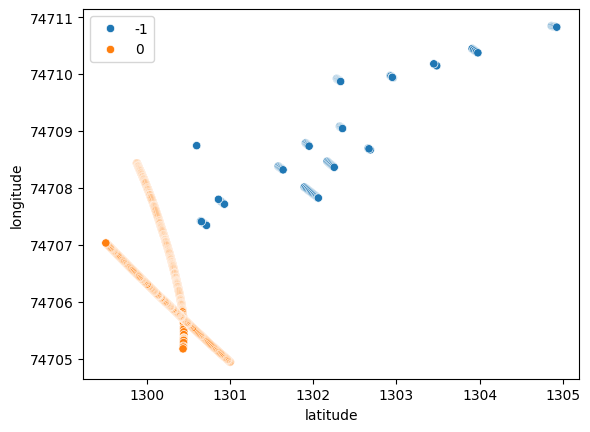

In [93]:
sns.scatterplot(data=coords_2d, 
                x='latitude', 
                y='longitude', 
                hue=dbscan_labels, 
                palette='tab10') ## This is a good palette for categorical data

# BAM!

We see that **DBSCAN** found one big cluster and bunch of outliers. Now let's see what happens with **K-means** clustering.

----

# Identifying clusters with K-means clustering, part 1

Using the same 2-dimensional dataset we just used, let's try to identify clusters with **K-means** clustering. The first thing we need to do for **K-means** clustering is find a good value for `K`. This is typically done using an **Elbow Graph**, although there are other methods.

Anyway, to draw an **Elbow Graph**, the first thing we need to do is calculate the **Within Cluster Sum of Squares**, or **WCSS**, for a range of values for `K`.

In [104]:
## Calculate within cluster sum of squares for a range of K values
wcss = []  ## within cluster sum of squares
k_range = range(1, 11) # Test K from 1 to 10

for k in k_range:

    ## create a KMmeans object that that will look for `k` clusters
    kmeans = KMeans(n_clusters=k, 
                    max_iter=10, ## max_iter is the maximum number of iterations,
                                 ## or centroid recalculation and point reassignment steps, 
                                 ## a single K-means run can do. 
                    n_init=10, ## n_init is the number K-means runs we'll do
                               ## each run with a different set of random starting points.
                    random_state=42)

    ## now apply the kmeans object to our data to calculate
    ## the wcss...
    ##
    ## NOTE: We're running kmeans.fit() in such a way that
    ##       we will supress divide by 0 errors. I belive the
    ##       outliers might be causing those.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)

        kmeans.fit(coords_2d)
        
    wcss.append(kmeans.inertia_) # The 'inertia_' attribute is the WCSS

Now that we've calculated the **Within Cluster Sum of Squares**, **WCSS**, for a range of values for `K`, we can draw an **Elbow Plot**. First, let's format the **WCSS** data...

In [105]:
## Plot the WCSS values to find the elbow
elbow_data = {
    'num_means': list(k_range),
    'wcss': wcss
}
elbow_df = pd.DataFrame(elbow_data)
elbow_df.head()

,num_means,wcss
0,1,1254.401470
1,2,528.817230
2,3,266.648199
3,4,179.635408
4,5,111.444183


Now let's draw the **Elbow Plot**...

<Axes: xlabel='num_means', ylabel='wcss'>

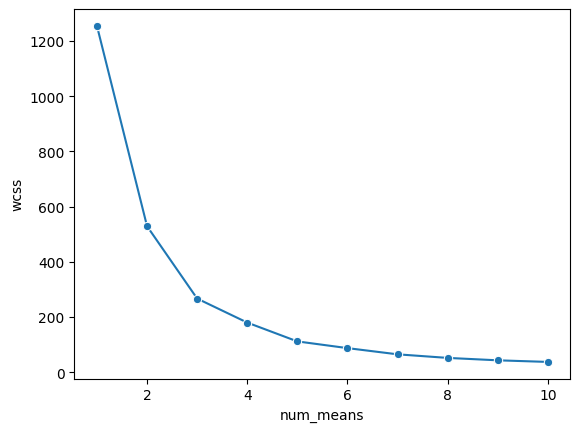

In [106]:
sns.lineplot(data=elbow_df, x='num_means', y='wcss', marker='o', dashes=False)

Looking at the **Elbow Plot** above, we can see that the **Within Cluster Sum of Squares** stops improving (getting significantly smaller) at around 7 clusters. So let's run **K-means** clustering with `n_clusters=7`.

In [107]:
kmeans = KMeans(n_clusters=7, 
                max_iter=10, ## max_iter is the maximum number of iterations,
                             ## or centroid recalculation and point reassignment steps, 
                             ## a single K-means run can do. 
                n_init=10, ## n_init is the number K-means runs we'll do
                           ## each run with a different set of random starting points.
                random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    k_means_labels = kmeans.fit_predict(coords_2d)

<Axes: xlabel='latitude', ylabel='longitude'>

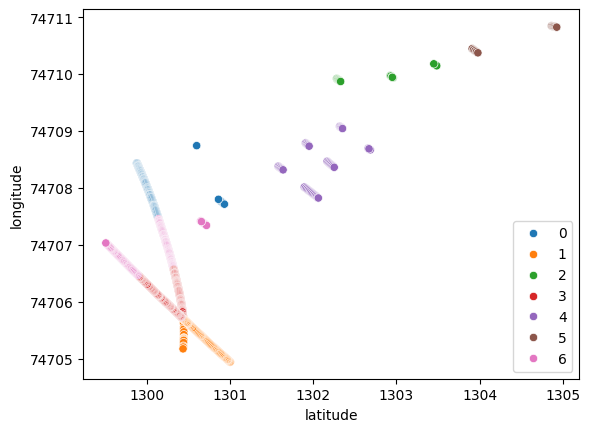

In [108]:
sns.scatterplot(data=coords_2d, x='latitude', y='longitude', hue=k_means_labels, palette='tab10')

# DOUBLE BAM!!

**K-means** finds more clusters by putting all of the outliers in their own cluster and splitting up the big cluster in smaller sub-clusters. I believe this might be due to how the clusters are based on the sum of squares - so the squared distance from the centroid can grow quite fast. If we wanted the big clusters to be just one cluster, we could set `n_clusters=2`, like this:

<Axes: xlabel='latitude', ylabel='longitude'>

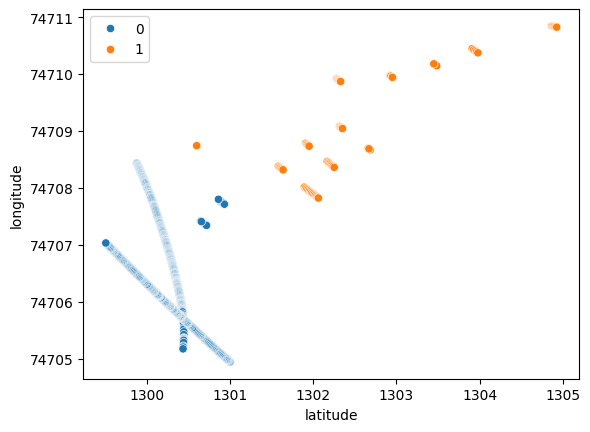

In [110]:
kmeans = KMeans(n_clusters=2, 
                max_iter=10, ## max_iter is the maximum number of iterations,
                             ## or centroid recalculation and point reassignment steps, 
                             ## a single K-means run can do. 
                n_init=10, ## n_init is the number K-means runs we'll do
                           ## each run with a different set of random starting points.
                random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    k_means_labels = kmeans.fit_predict(coords_2d)

sns.scatterplot(data=coords_2d, x='latitude', y='longitude', hue=k_means_labels, palette='tab10')

And the result is similar to what we got with **DBSCAN**, but not the same. Some of the outliers are included in the big cluster. Now let's include `depth` in our cluster analysis and see what happens.

----

# Clustering data with more than 2 dimensions

Now that we've seen how to find clusters in 2-d data, let's learn how to work with data with more than 2 dimensions. Specifically, now let's include 'depth' in our dataset, which means that dataset will have 3 dimensions.

In [111]:
## create a 3-d dataset with latitude, longitude and depth
coords_3d = geochem_data[['latitude', 'longitude', 'depth']]
coords_3d.head()

,latitude,longitude,depth
0,1304.863397,74710.84587,-420.016808
1,1304.875714,74710.84154,-420.047116
2,1304.887496,74710.83741,-420.076037
3,1304.899862,74710.83307,-420.106322
4,1304.912803,74710.82849,-420.137974


To plot a dataset with more than 2 dimensions, we'll start by reducing the dimensions to 2 with **Principal Component Analysis**, **PCA**.

The first thing you always do for **PCA** is standardize the data. By *standardize*, we mean that we subtract the mean and divide by the standard deviation. This centers the data and gives is a standard deviation of 1.

In [113]:
## Standardize the Data (Crucial for PCA)
## PCA is affected by scale, so features should have a mean of 0 and std of 1.
scaler = StandardScaler()
coords_3d_scaled = scaler.fit_transform(coords_3d)

Now that we've standardized the data, we can run `PCA()` on it. We'll tell it to reduce the dimensions to 2 with `n_components=2`.

In [140]:
pca = PCA(n_components=2)
coords_pca = pca.fit_transform(coords_3d_scaled)

## print out the shape to make sure we  now only have 
## 2 columns instead of 3...
coords_pca.shape ## (# rows, # columns)

(499, 2)

In [142]:
## print the first few rows
## NOTE: coords_pca is an ndarray from numpy, so we
##       can't just use head()...
coords_pca[:5, :]

array([[5.34624314, 1.92881018],
       [5.3381634 , 1.9504188 ],
       [5.33047153, 1.97106316],
       [5.32242623, 1.99271105],
       [5.31400812, 2.01536364]])

In [146]:
## ...or we can convert the ndarray to a dataframe and use head()
coords_pca_df = pd.DataFrame(coords_pca)
coords_pca_df.head()

,0,1
0,5.346243,1.928810
1,5.338163,1.950419
2,5.330472,1.971063
3,5.322426,1.992711
4,5.314008,2.015364


In [147]:
## change the column names to PC1 and PC2
coords_pca_df.columns = ['PC1', 'PC2']
coords_pca_df.head()

,PC1,PC2
0,5.346243,1.928810
1,5.338163,1.950419
2,5.330472,1.971063
3,5.322426,1.992711
4,5.314008,2.015364


Now let's draw a **skree plot** to see how much variation each principal complent accounts for. We first calculate the amount of variation each PC accounts for and create labels for our graph, then we draw the graph...

/var/folders/sz/w2x93nq13vd2hbfn8jk9dtvh0000gn/T/ipykernel_5993/3055277085.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


[Text(0, 0, 'PC1'), Text(1, 0, 'PC2')]

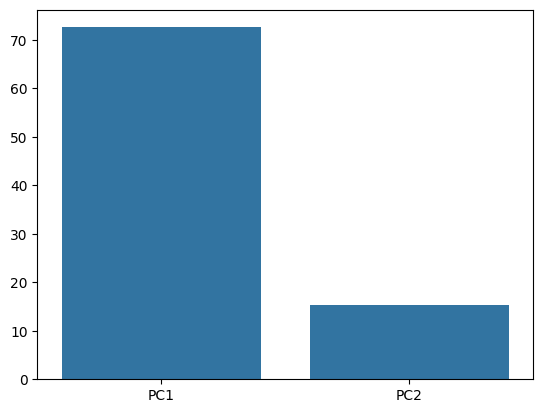

In [148]:
## draw a scree plot...
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

ax = sns.barplot(per_var)
# Set the new x-tick labels
ax.set_xticklabels(labels)

So it looks like PC1 and PC2 accoutn for about 90% of the total variation in the data, which is pretty good.

Now let's draw a scatter plot using PC1 and PC2 as the x and y-axis coordinates.

<Axes: xlabel='PC1', ylabel='PC2'>

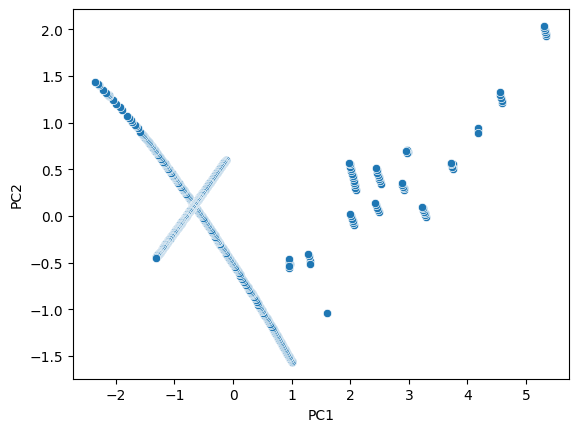

In [149]:
sns.scatterplot(data=coords_pca_df, x='PC1', y='PC2')

## BAM!

Adding `depth` to our dataset and then reducing the dimensions to 2 results in a similar graph as before, but the "big cluster" looks a little different now, more streatched out in one way and more compressed in another.

Now let's look for clusters in the data.

----

# Identifying clusters with DBSCAN, part 2, 3-d dataset

Identifying clusters with **DBSCAN** is just like before. However, because `depth` looks like it's on a different scale, we use the values in `coords_3d_scaled` instead of the raw values in `coords_3d`.

In [151]:
## Epsilon is the maximum distance between two samples
## for one to be considered as in the neighborhood of the other.
epsilon = 0.25

## The number of samples in a neighborhood for a point 
## to be considered as a core point.
min_samples = 15

## create a DBSCAN object
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

## run DBSCAN on the data
dbscan.fit(coords_3d_scaled) ## NOTE: This is the scaled 3d data,
                             ## not the 2d PCA transformed data. The
                             ## PCA transformed data is just for visualization

# Get the cluster labels
dbscan_labels = dbscan.labels_

unique_labels = set(dbscan_labels)
unique_labels

{np.int64(-1), np.int64(0), np.int64(1)}

<Axes: xlabel='PC1', ylabel='PC2'>

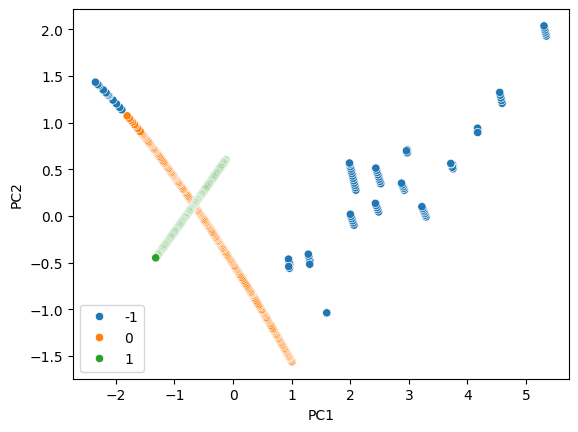

In [152]:
sns.scatterplot(data=coords_pca_df, x='PC1', y='PC2', hue=dbscan_labels, palette='tab10')

# BAM!

Now let's look for clustes with **K-means** clustering.

----

# Identifying clusters with K-means, part 2, 3-d dataset

**K-means** for 3d data is just like before. However, because `depth` looks like it's on a different scale, we use the values in `coords_3d_scaled` instead of the raw values in `coords_3d`.

In [153]:
## Calculate within cluster sum of squares for a range of K values
wcss = []  ## within cluster sum of squares
k_range = range(1, 11) # Test K from 1 to 10

for k in k_range:
    
    kmeans = KMeans(n_clusters=k, 
                    max_iter=10, ## max_iter is the maximum number of iterations,
                                 ## or centroid recalculation and point reassignment steps, 
                                 ## a single K-means run can do. 
                    n_init=10, ## n_init is the number K-means runs we'll do
                               ## each run with a different set of random starting points. 
                    random_state=42)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)

        kmeans.fit(coords_3d_scaled)
        
    wcss.append(kmeans.inertia_) # The 'inertia_' attribute is the WCSS

In [154]:
## Plot the WCSS values to find the elbow
elbow_data = {
    'num_means': list(k_range),
    'wcss': wcss
}
elbow_df = pd.DataFrame(elbow_data)
elbow_df.head()

,num_means,wcss
0,1,1497.000000
1,2,702.620216
2,3,430.082037
3,4,281.882642
4,5,206.061644


<Axes: xlabel='num_means', ylabel='wcss'>

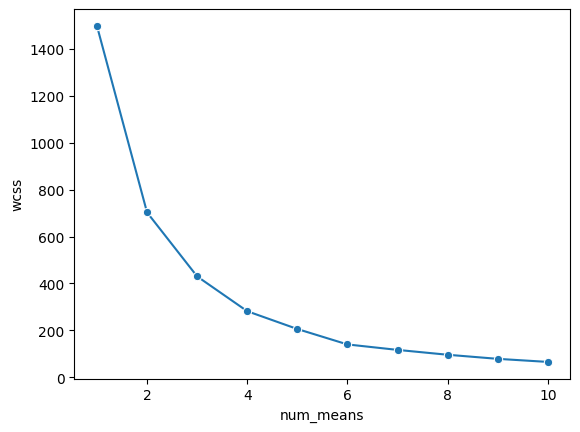

In [155]:
sns.lineplot(data=elbow_df, x='num_means', y='wcss', marker='o', dashes=False)

In [156]:
kmeans = KMeans(n_clusters=7, 
                max_iter=10, ## max_iter is the maximum number of iterations,
                             ## or centroid recalculation and point reassignment steps, 
                             ## a single K-means run can do. 
                n_init=10, ## n_init is the number K-means runs we'll do
                           ## each run with a different set of random starting points. 
                random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    k_means_labels = kmeans.fit_predict(coords_3d_scaled)

<Axes: xlabel='PC1', ylabel='PC2'>

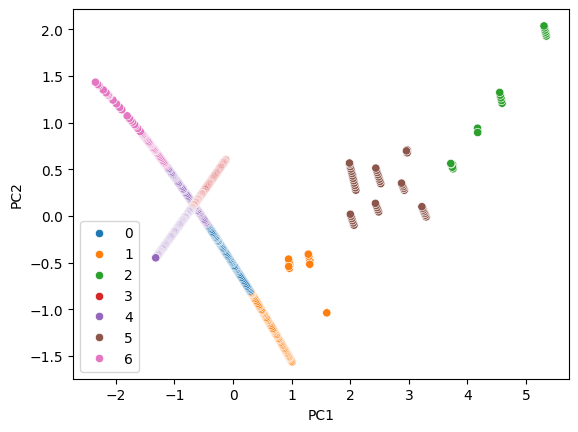

In [157]:
sns.scatterplot(data=coords_pca_df, x='PC1', y='PC2', hue=k_means_labels, palette='tab10')

# BAM!

Now let's see what happens if we restrict the number of clusters to 3, to match the number of clusters (plus outliers) we found with **DBSCAN**.

<Axes: xlabel='PC1', ylabel='PC2'>

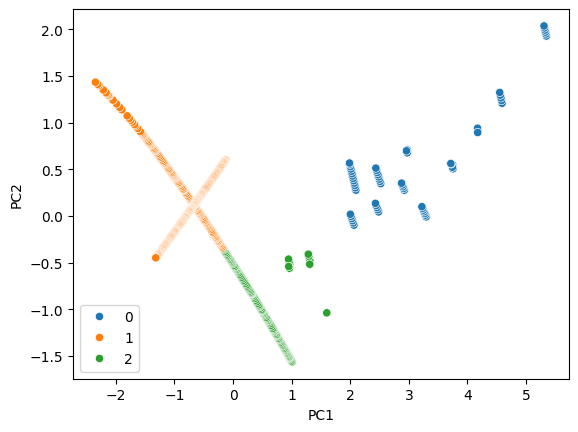

In [158]:
kmeans = KMeans(n_clusters=3, 
                max_iter=10, ## max_iter is the maximum number of iterations,
                             ## or centroid recalculation and point reassignment steps, 
                             ## a single K-means run can do. 
                n_init=10, ## n_init is the number K-means runs we'll do
                           ## each run with a different set of random starting points.  
                random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    k_means_labels = kmeans.fit_predict(coords_3d_scaled)

sns.scatterplot(data=coords_pca_df, x='PC1', y='PC2', hue=k_means_labels, palette='tab10')

bam.